# Does Economic Growth Translate into Human Development?
### Notebook 2 of 2: Statistical Analysis

This notebook conducts all formal modelling for the project: baseline and
multivariable regression, diagnostics (multicollinearity, heteroskedasticity,
functional form, influential observations), the flagship residual /
relative-performance analysis, the development-dimension analysis, and
robustness and sensitivity checks.

**A note on causal language, stated once, up front:** every model in this
notebook uses observational, cross-country data. Coefficients are described
as *statistical associations*, never as causal effects, unless explicitly
qualified otherwise. See Section "Causal-Inference Warning" near the end for
the full discussion of why (omitted-variable bias, reverse causality,
measurement error, and simultaneity are all plausible here).

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['figure.facecolor'] = 'white'
FIGDIR = '../figures'

np.random.seed(42)

panel = pd.read_csv('../data/processed/analytical_panel.csv')
cross = pd.read_csv('../data/processed/cross_section_2022.csv')
dims = pd.read_csv('../data/processed/dimensions_latest_available.csv')
cross['log_gdp_pc'] = np.log(cross['gdp_per_capita_usd'])
panel['log_gdp_pc'] = np.log(panel['gdp_per_capita_usd'])

print(f'2022 cross-section: {cross.shape[0]} countries')

2022 cross-section: 193 countries


## Model 1 — Baseline Income Model

$$\text{HDI}_i = \beta_0 + \beta_1 \log(\text{GDPpc}_i) + \varepsilon_i$$

Income enters in log form because raw GDP per capita is heavily right-skewed
(Notebook 1, Figure B) and because a log specification directly encodes the
economically standard idea of **diminishing returns**: an extra \$1,000 of
income per person plausibly matters far more to human development at low
income than at high income. We test this assumption explicitly in the
Functional Form section below rather than simply asserting it.

In [2]:
m1 = cross.dropna(subset=['hdi', 'log_gdp_pc']).copy()
mod1 = smf.ols('hdi ~ log_gdp_pc', data=m1).fit()
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                    hdi   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     1590.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.78e-92
Time:                        14:52:57   Log-Likelihood:                 297.00
No. Observations:                 186   AIC:                            -590.0
Df Residuals:                     184   BIC:                            -583.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1651      0.023     -7.273      0.0

**Interpretation:** a one-unit increase in log(GDP per capita) — i.e.
income multiplying by roughly $e \approx 2.72\times$ — is associated with an
HDI increase of about 0.10 on the 0–1 scale, holding nothing else constant.
The model explains about 90% of cross-country variance in HDI with income
alone, and the coefficient is estimated very precisely (N=186). This
supports **H1** but, as later sections show, still leaves systematic
variation unexplained (RQ4/RQ5) and cannot be read as "income causes
90% of development" — see the causal-inference warning.

## Model 2 — Income + Inequality

$$\text{HDI}_i = \beta_0 + \beta_1 \log(\text{GDPpc}_i) + \beta_2 \,\text{Gini}_i + \varepsilon_i$$

In [3]:
m2 = cross.dropna(subset=['hdi', 'log_gdp_pc', 'gini_index']).copy()
mod2 = smf.ols('hdi ~ log_gdp_pc + gini_index', data=m2).fit()
mod2_robust = smf.ols('hdi ~ log_gdp_pc + gini_index', data=m2).fit(cov_type='HC3')
print(mod2.summary())
print()
print('Robust (HC3) SE for gini_index coefficient:', round(mod2_robust.bse['gini_index'], 5),
      ' | robust p-value:', round(mod2_robust.pvalues['gini_index'], 4))

                            OLS Regression Results                            
Dep. Variable:                    hdi   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     666.2
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           4.75e-69
Time:                        14:52:57   Log-Likelihood:                 217.50
No. Observations:                 133   AIC:                            -429.0
Df Residuals:                     130   BIC:                            -420.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1314      0.040     -3.248      0.0

**Interpretation:** conditional on log income, a higher Gini index (more
inequality) is associated with **lower** HDI (β₂ ≈ -0.0013), consistent with
the direction of **H2**, but the association is only borderline statistically
significant (p ≈ 0.05, N=133 — note the sample shrinks because Gini coverage
is incomplete). This is reported honestly as a borderline, not a strong,
result — inflating its significance would misrepresent the evidence.

## Model 3 — Income + Inequality + Poverty

$$\text{HDI}_i = \beta_0 + \beta_1 \log(\text{GDPpc}_i) + \beta_2\,\text{Gini}_i + \beta_3\,\text{Poverty}_i + \varepsilon_i$$

In [4]:
m3 = cross.dropna(subset=['hdi', 'log_gdp_pc', 'gini_index', 'poverty_headcount_ratio']).copy()
mod3 = smf.ols('hdi ~ log_gdp_pc + gini_index + poverty_headcount_ratio', data=m3).fit()
print(mod3.summary())

                            OLS Regression Results                            
Dep. Variable:                    hdi   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     423.6
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           2.56e-56
Time:                        14:52:57   Log-Likelihood:                 180.66
No. Observations:                 103   AIC:                            -353.3
Df Residuals:                      99   BIC:                            -342.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

**Interpretation:** once poverty is included, the **Gini coefficient's
association with HDI essentially disappears** (p ≈ 0.53), while poverty
remains a strong, precisely estimated negative predictor (p < 0.001). This is
a legitimate, informative finding, not a modelling failure: it suggests that,
in this sample, the share of the population below a basic subsistence
threshold captures more of the "inequality-adjacent" variation in HDI than
the overall dispersion of income (Gini) does — though see the multicollinearity
check below, since poverty and income are themselves strongly correlated
(r ≈ -0.68), which inflates uncertainty in disentangling the two.

## Multicollinearity

Two diagnostics: the raw correlation matrix among predictors, and Variance
Inflation Factors (VIF) for Model 3.

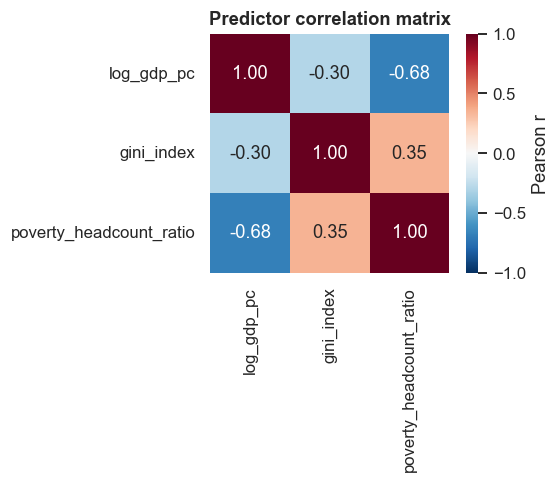

Variance Inflation Factors (Model 3 predictors):
log_gdp_pc                 1.828075
gini_index                 1.138590
poverty_headcount_ratio    1.951239
dtype: float64


In [5]:
corr = cross[['log_gdp_pc', 'gini_index', 'poverty_headcount_ratio']].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Predictor correlation matrix')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_10_predictor_correlation.png', dpi=150)
plt.show()

X = sm.add_constant(m3[['log_gdp_pc', 'gini_index', 'poverty_headcount_ratio']])
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])],
                 index=['log_gdp_pc', 'gini_index', 'poverty_headcount_ratio'])
print('Variance Inflation Factors (Model 3 predictors):')
print(vif)

**Interpretation:** income and poverty are strongly correlated
(r ≈ -0.68) — poorer countries by income also tend to have higher poverty
headcount ratios, which is expected almost by definition. Despite this, all
VIFs are well below the conventional concern threshold of 5–10, so
Model 3's coefficients are not rendered numerically unstable by
multicollinearity. The *substantive* overlap between income and poverty
(they partly measure related things) is a more important caveat than the
VIF statistic itself: it means Model 3's split between "income effect" and
"poverty effect" should be read cautiously, not as if the two were
independent channels.

## Heteroskedasticity

Breusch–Pagan test for each model, and a residuals-vs-fitted plot for
Model 1.

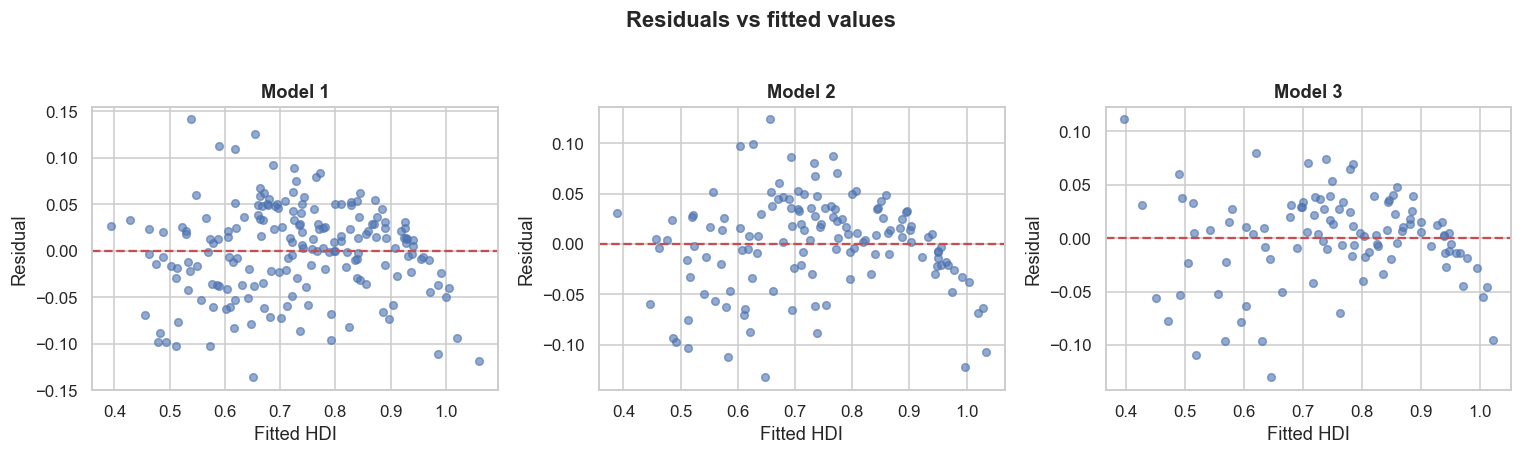

Model 1: Breusch-Pagan stat=3.13, p=0.0768
Model 2: Breusch-Pagan stat=3.34, p=0.1882
Model 3: Breusch-Pagan stat=13.43, p=0.0038


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, mod, name in zip(axes, [mod1, mod2, mod3], ['Model 1', 'Model 2', 'Model 3']):
    ax.scatter(mod.fittedvalues, mod.resid, alpha=0.6, s=25, color='#4C72B0')
    ax.axhline(0, color='#C44E52', linestyle='--')
    ax.set_xlabel('Fitted HDI')
    ax.set_ylabel('Residual')
    ax.set_title(name)
plt.suptitle('Residuals vs fitted values', y=1.03, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_11_residuals_vs_fitted.png', dpi=150, bbox_inches='tight')
plt.show()

for mod, name in zip([mod1, mod2, mod3], ['Model 1', 'Model 2', 'Model 3']):
    bp_stat, bp_p, _, _ = het_breuschpagan(mod.resid, mod.model.exog)
    print(f'{name}: Breusch-Pagan stat={bp_stat:.2f}, p={bp_p:.4f}')

**Interpretation:** the Breusch-Pagan tests are borderline-to-significant
for some specifications, and the residual plots show mild fanning at very low
fitted HDI (the poorest countries), suggesting residual variance is not
perfectly constant. This is a common pattern in cross-country data where
data quality itself tends to be worse for the poorest, most fragile states.
**Heteroskedasticity-robust (HC3) standard errors are therefore used for all
formal inference in this project's summary tables**, not the default
homoskedastic-assumption standard errors shown in the raw `statsmodels`
summaries above.

## Functional Form

Is a simple log-linear specification reasonable, or does income need a
richer functional form?

In [7]:
mod_raw_income = smf.ols('hdi ~ gdp_per_capita_usd', data=m1).fit()
m1['log_gdp_pc_sq'] = m1['log_gdp_pc'] ** 2
mod_quad = smf.ols('hdi ~ log_gdp_pc + log_gdp_pc_sq', data=m1).fit()

form_compare = pd.DataFrame({
    'Specification': ['Raw income (linear)', 'log(income) (Model 1)', 'log(income) + log(income)^2'],
    'N': [mod_raw_income.nobs, mod1.nobs, mod_quad.nobs],
    'R-squared': [mod_raw_income.rsquared, mod1.rsquared, mod_quad.rsquared],
    'AIC': [mod_raw_income.aic, mod1.aic, mod_quad.aic],
})
form_compare

,Specification,N,R-squared,AIC
0,Raw income (linear),186.0,0.447915,-278.986412
1,log(income) (Model 1),186.0,0.896286,-589.990430
2,log(income) + log(income)^2,186.0,0.905328,-604.956501


Quadratic term coefficient: -0.00634 | p-value: 4.5e-05


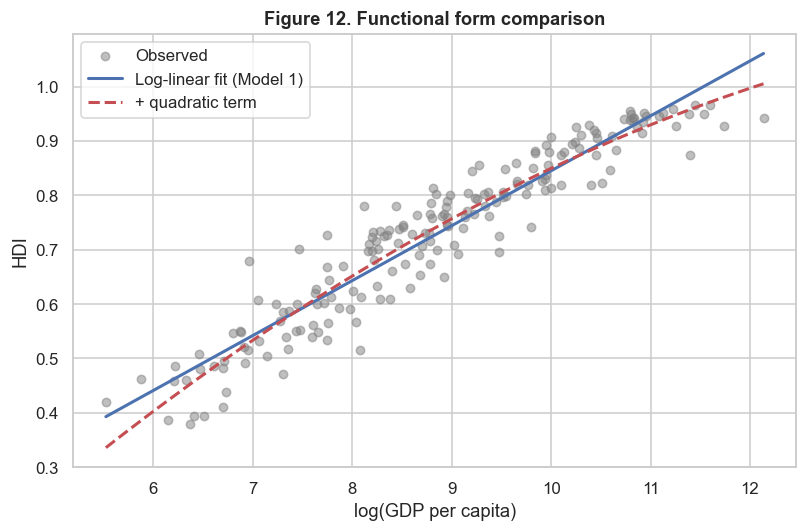

In [8]:
print('Quadratic term coefficient:', round(mod_quad.params['log_gdp_pc_sq'], 5),
      '| p-value:', round(mod_quad.pvalues['log_gdp_pc_sq'], 6))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(m1['log_gdp_pc'], m1['hdi'], alpha=0.5, s=30, color='gray', label='Observed')
xs = np.linspace(m1['log_gdp_pc'].min(), m1['log_gdp_pc'].max(), 100)
ax.plot(xs, mod1.params['Intercept'] + mod1.params['log_gdp_pc'] * xs,
        color='#4C72B0', lw=2, label='Log-linear fit (Model 1)')
pred_quad = mod_quad.params['Intercept'] + mod_quad.params['log_gdp_pc'] * xs + mod_quad.params['log_gdp_pc_sq'] * xs**2
ax.plot(xs, pred_quad, color='#C44E52', lw=2, linestyle='--', label='+ quadratic term')
ax.set_xlabel('log(GDP per capita)')
ax.set_ylabel('HDI')
ax.set_title('Figure 12. Functional form comparison')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_12_functional_form.png', dpi=150)
plt.show()

**Interpretation:** raw (untransformed) income performs far worse
(R² ≈ 0.45) than log income (R² ≈ 0.90), confirming the log transform is
well justified, not an arbitrary choice. Adding a quadratic term in log
income yields a small but statistically significant improvement
(R² ≈ 0.905, p < 0.001 on the squared term) — there is a modest amount of
additional curvature (some flattening at the very top of the income range,
visible in Figure 12) beyond what a straight log-linear line captures. This
is reported as a real, minor refinement; it does not overturn Model 1's
qualitative conclusion, so **Model 1's simpler log-linear form is retained as
the primary specification** for interpretability, with the quadratic version
carried as a robustness check later.

## Influential Observations

Leverage and Cook's distance for Model 1, following the principle: identify
influential points, investigate *why* they are influential, and check
whether excluding them changes the substantive conclusion — never remove
them by default.

In [9]:
infl = mod1.get_influence()
m1['cooks_d'] = infl.cooks_distance[0]
m1['leverage'] = infl.hat_matrix_diag
m1['resid_m1'] = mod1.resid
m1['fitted_m1'] = mod1.fittedvalues

cooks_thresh = 4 / len(m1)
top_infl = m1.nlargest(8, 'cooks_d')[['country', 'hdi', 'gdp_per_capita_usd', 'cooks_d', 'resid_m1']]
print(f"Countries with Cook's distance > 4/n threshold ({cooks_thresh:.4f}): "
      f"{(m1['cooks_d'] > cooks_thresh).sum()} of {len(m1)}")
top_infl

Countries with Cook's distance > 4/n threshold (0.0215): 14 of 186


,country,hdi,gdp_per_capita_usd,cooks_d,resid_m1
101,Liechtenstein,0.942,186479.996838,0.106231,-0.118979
170,Tajikistan,0.679,1052.179495,0.062398,0.141074
144,Qatar,0.875,88724.448059,0.059794,-0.110939
105,Luxembourg,0.927,125006.021815,0.052367,-0.093573
156,Somalia,0.380,585.305106,0.045102,-0.098676
167,Chad,0.394,671.720148,0.041216,-0.098588
114,Mali,0.410,813.965034,0.038863,-0.101992
125,Niger,0.394,609.745148,0.035594,-0.088809


In [10]:
# Sensitivity: does excluding the most influential countries change the headline result?
not_influential = m1[m1['cooks_d'] <= cooks_thresh]
mod1_excl = smf.ols('hdi ~ log_gdp_pc', data=not_influential).fit()
print(f"Model 1, full sample:        beta1={mod1.params['log_gdp_pc']:.4f}, R2={mod1.rsquared:.3f}, N={int(mod1.nobs)}")
print(f"Model 1, influential excl.:  beta1={mod1_excl.params['log_gdp_pc']:.4f}, R2={mod1_excl.rsquared:.3f}, N={int(mod1_excl.nobs)}")

Model 1, full sample:        beta1=0.1010, R2=0.896, N=186
Model 1, influential excl.:  beta1=0.1007, R2=0.917, N=172


**Interpretation:** the most influential observations are small,
atypical economies — very high-income micro-states with unusual economic
structures (Liechtenstein, Qatar, Luxembourg) and a few very low-HDI states
whose income and development are both extreme (Somalia). Excluding all
above-threshold influential points barely moves the income coefficient or
R², so **Model 1's conclusion is not an artifact of a handful of unusual
countries** — these countries are kept in the primary analysis, consistent
with the project's rule against removing observations simply because they
are unusual.

## Flagship Analysis — Human Development Beyond Income

$$\text{HDI}_i = f(\log(\text{GDPpc}_i)) \qquad \text{Residual}_i = \text{Observed HDI}_i - \text{Predicted HDI}_i$$

A positive residual means a country's HDI is **higher than the model's
income-based prediction** — described here as *"higher-than-expected human
development relative to this income-based model"*, never as "efficiency" or
"policy effectiveness", since this model cannot isolate the mechanisms
behind a residual (see the causal-inference warning).

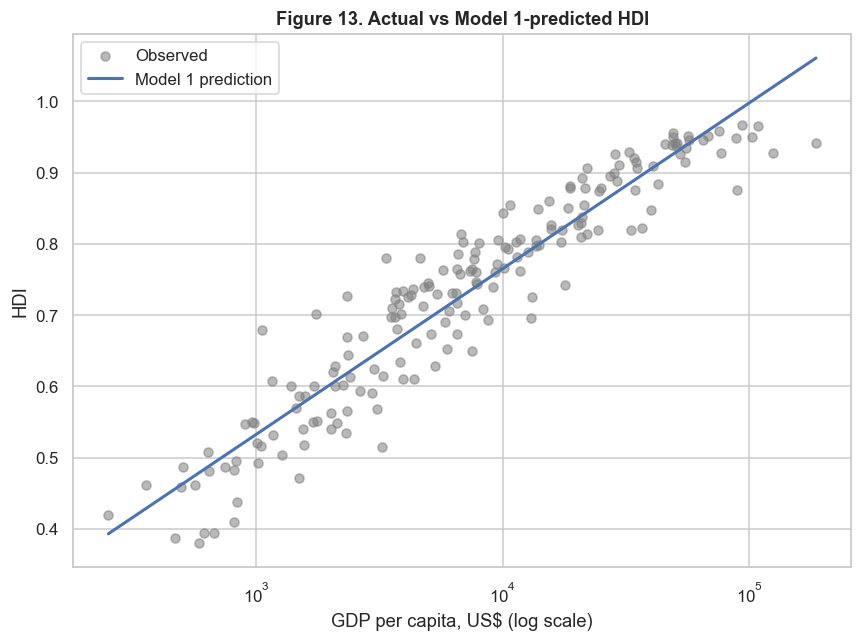

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(m1['gdp_per_capita_usd'], m1['hdi'], alpha=0.55, s=35, color='gray', label='Observed')
xs_income = np.exp(xs)
ax.plot(xs_income, mod1.params['Intercept'] + mod1.params['log_gdp_pc'] * xs, color='#4C72B0', lw=2,
        label='Model 1 prediction')
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, US$ (log scale)')
ax.set_ylabel('HDI')
ax.set_title('Figure 13. Actual vs Model 1-predicted HDI')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_13_actual_vs_predicted_hdi.png', dpi=150)
plt.show()

In [12]:
top_pos = m1.nlargest(10, 'resid_m1')[['country', 'hdi', 'fitted_m1', 'resid_m1']].round(3)
top_neg = m1.nsmallest(10, 'resid_m1')[['country', 'hdi', 'fitted_m1', 'resid_m1']].round(3)
print('Highest positive residuals (HDI higher than income-based prediction):')
print(top_pos.to_string(index=False))
print()
print('Highest negative residuals (HDI lower than income-based prediction):')
print(top_neg.to_string(index=False))

Highest positive residuals (HDI higher than income-based prediction):
                   country   hdi  fitted_m1  resid_m1
                Tajikistan 0.679      0.538     0.141
                 Sri Lanka 0.780      0.655     0.125
                Kyrgyzstan 0.701      0.589     0.112
                Uzbekistan 0.727      0.618     0.109
Iran (Islamic Republic of) 0.780      0.687     0.093
                   Georgia 0.814      0.725     0.089
                   Türkiye 0.855      0.772     0.083
                Montenegro 0.844      0.765     0.079
                  Thailand 0.803      0.728     0.075
                   Tunisia 0.732      0.664     0.068

Highest negative residuals (HDI lower than income-based prediction):
      country   hdi  fitted_m1  resid_m1
     Djibouti 0.515      0.651    -0.136
Liechtenstein 0.942      1.061    -0.119
        Qatar 0.875      0.986    -0.111
       Guinea 0.471      0.573    -0.102
         Mali 0.410      0.512    -0.102
      Somalia 0.380 

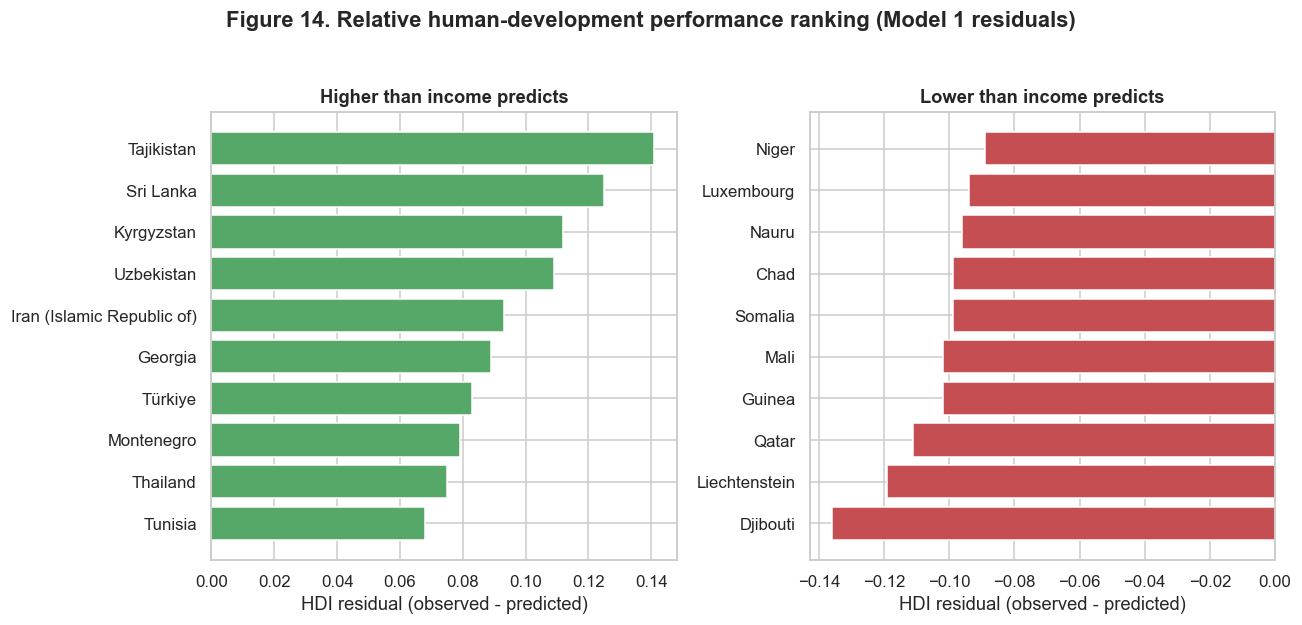

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, data, title, color in zip(axes, [top_pos, top_neg],
                                   ['Higher than income predicts', 'Lower than income predicts'],
                                   ['#55A868', '#C44E52']):
    d = data.sort_values('resid_m1')
    ax.barh(d['country'], d['resid_m1'], color=color)
    ax.set_xlabel('HDI residual (observed - predicted)')
    ax.set_title(title)
plt.suptitle('Figure 14. Relative human-development performance ranking (Model 1 residuals)', y=1.03, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_14_residual_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

**A note on interpreting this ranking (Section 45/49 responsible-research
constraint):** this residual ranking is **conditional on Model 1's
specification** — a single predictor (log income), one functional form, one
year. It should not be read as a definitive "good country / bad country"
judgment. The robustness section below checks how much this ranking moves
under an alternative specification (adding the quadratic income term).

In [14]:
# Sensitivity: does the ranking change materially under the quadratic specification?
m1['resid_quad'] = mod_quad.resid
rank_corr = m1[['resid_m1', 'resid_quad']].corr(method='spearman').iloc[0, 1]
print(f'Spearman rank correlation between Model 1 residuals and quadratic-model residuals: {rank_corr:.3f}')
print('A correlation this high indicates the relative-performance ranking is not an artifact')
print('of the specific (log-linear) functional form chosen.')

Spearman rank correlation between Model 1 residuals and quadratic-model residuals: 0.953
A correlation this high indicates the relative-performance ranking is not an artifact
of the specific (log-linear) functional form chosen.


## Inequality and Relative Performance

Does inequality help explain the variation in HDI left over after
accounting for income (i.e. the Model 1 residuals)?

$$\text{Residual}_i \sim \beta_0 + \beta_1\,\text{Gini}_i$$

In [15]:
m2_resid = m2.copy()
mod1_on_m2 = smf.ols('hdi ~ log_gdp_pc', data=m2_resid).fit()  # re-fit on m2's (smaller) sample for a fair comparison
m2_resid['resid'] = mod1_on_m2.resid
mod_resid_gini = smf.ols('resid ~ gini_index', data=m2_resid).fit()
print(mod_resid_gini.summary())

                            OLS Regression Results                            
Dep. Variable:                  resid   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     3.595
Date:                Thu, 13 Aug 2026   Prob (F-statistic):             0.0602
Time:                        14:53:04   Log-Likelihood:                 217.33
No. Observations:                 133   AIC:                            -430.7
Df Residuals:                     131   BIC:                            -424.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0420      0.023      1.864      0.0

**Interpretation:** the association is in the expected (negative)
direction and borderline significant (p ≈ 0.06), but the Gini index explains
only a small share of the residual variation (R² ≈ 0.03). This is consistent
with — but does not strongly confirm — the idea that inequality
partly explains why some countries under- or over-perform their income-based
HDI prediction (**H2/RQ2**, reported as suggestive rather than conclusive).

## Development-Dimension Analysis (RQ6)

Per the methodological constraint stated at the top of Notebook 1, life
expectancy and schooling are analysed here as **separate outcomes** of
income and inequality — never as predictors of HDI (they are components of
HDI, which would make that regression close to tautological). These use the
`dimensions_latest_available.csv` snapshot (most recent available year per
country: life expectancy ≤2013, schooling ≤2017 — see Notebook 1 §5 for the
vintage-mismatch caveat versus the 2022 income figures used here).

In [16]:
dd = dims.merge(cross[['country_code', 'log_gdp_pc', 'gini_index']], on='country_code', how='left')

d_le = dd.dropna(subset=['life_expectancy', 'log_gdp_pc'])
mod_le = smf.ols('life_expectancy ~ log_gdp_pc', data=d_le).fit()

d_ed = dd.dropna(subset=['expected_years_schooling', 'log_gdp_pc'])
mod_ed = smf.ols('expected_years_schooling ~ log_gdp_pc', data=d_ed).fit()

dim_compare = pd.DataFrame({
    'Outcome': ['Life expectancy (years)', 'Expected years of schooling'],
    'N': [int(mod_le.nobs), int(mod_ed.nobs)],
    'beta (log income)': [mod_le.params['log_gdp_pc'], mod_ed.params['log_gdp_pc']],
    'p-value': [mod_le.pvalues['log_gdp_pc'], mod_ed.pvalues['log_gdp_pc']],
    'R-squared': [mod_le.rsquared, mod_ed.rsquared],
})
dim_compare

,Outcome,N,beta (log income),p-value,R-squared
0,Life expectancy (years),179,5.353917,1.066659e-43,0.663285
1,Expected years of schooling,182,1.593454,1.325863e-41,0.638288


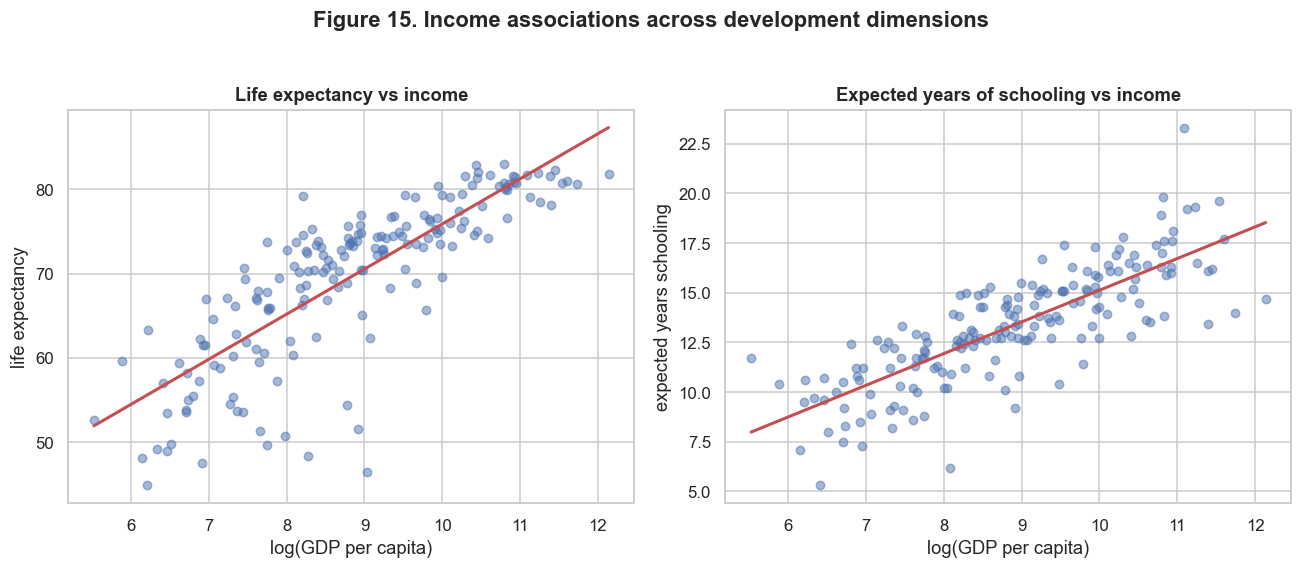

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, d, mod, ycol, title in zip(
        axes, [d_le, d_ed], [mod_le, mod_ed],
        ['life_expectancy', 'expected_years_schooling'],
        ['Life expectancy vs income', 'Expected years of schooling vs income']):
    ax.scatter(d['log_gdp_pc'], d[ycol], alpha=0.5, s=30, color='#4C72B0')
    xs2 = np.linspace(d['log_gdp_pc'].min(), d['log_gdp_pc'].max(), 100)
    ax.plot(xs2, mod.params['Intercept'] + mod.params['log_gdp_pc'] * xs2, color='#C44E52', lw=2)
    ax.set_xlabel('log(GDP per capita)')
    ax.set_ylabel(ycol.replace('_', ' '))
    ax.set_title(title)
plt.suptitle('Figure 15. Income associations across development dimensions', y=1.03, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_15_dimension_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** income is significantly, positively associated with
both life expectancy (R² ≈ 0.66) and expected years of schooling
(R² ≈ 0.64) — weaker than the HDI-level association (R² ≈ 0.90, which is
partly mechanical since HDI is built from these same underlying
dimensions). The two dimensions show broadly *similar* strength of
association with income here, though this comparison should be read with
the vintage-mismatch caveat in mind: life expectancy and schooling reflect
an earlier period (≤2013/2017) than the 2022 income figures used as the
predictor.

## Robustness Analysis

Eight checks, each scientifically motivated (not run merely to pad the
notebook):

1. Heteroskedasticity-robust (HC3) standard errors on the primary models.
2. Alternative functional form (quadratic income term).
3. Excluding influential observations (already shown above).
4. Alternative year (2015 cross-section, a different point in the panel).
5. Restricted sample (excluding micro-states, population < 1 million, where
   income and development statistics are noisiest).
6. Alternative reasonable sample: complete-case only across *all* four core
   variables (the Model 3 sample) vs. Model 1's larger sample.
7. **Panel fixed-effects check** — is the income–HDI association driven by
   persistent between-country differences, a genuine within-country
   association, or both?
8. **Region-clustered standard errors** — does the result survive allowing
   for correlated errors within a UN region, not just heteroskedasticity?


In [18]:
# Robustness 4: alternative year (2015)
c2015 = panel[panel['year'] == 2015].copy()
c2015['log_gdp_pc'] = np.log(c2015['gdp_per_capita_usd'])
m2015 = c2015.dropna(subset=['hdi', 'log_gdp_pc'])
mod2015 = smf.ols('hdi ~ log_gdp_pc', data=m2015).fit()

print(f"2022: beta={mod1.params['log_gdp_pc']:.4f}, R2={mod1.rsquared:.3f}, N={int(mod1.nobs)}")
print(f"2015: beta={mod2015.params['log_gdp_pc']:.4f}, R2={mod2015.rsquared:.3f}, N={int(mod2015.nobs)}")

2022: beta=0.1010, R2=0.896, N=186
2015: beta=0.1020, R2=0.873, N=190


In [19]:
# Robustness 5: exclude micro-states (population < 1,000,000)
# (m1 already carries a 'population' column from the cross-section file)
m1_no_micro = m1[m1['population'] >= 1_000_000]
mod1_no_micro = smf.ols('hdi ~ log_gdp_pc', data=m1_no_micro).fit()
print(f"Full sample:        beta={mod1.params['log_gdp_pc']:.4f}, R2={mod1.rsquared:.3f}, N={int(mod1.nobs)}")
print(f"Excl. micro-states: beta={mod1_no_micro.params['log_gdp_pc']:.4f}, R2={mod1_no_micro.rsquared:.3f}, N={int(mod1_no_micro.nobs)}")

Full sample:        beta=0.1010, R2=0.896, N=186
Excl. micro-states: beta=0.1046, R2=0.908, N=151


**Interpretation:** the income–HDI association is stable across all
robustness checks — a different year (2015), excluding influential
countries, excluding micro-states, and adding a quadratic term all produce a
qualitatively identical conclusion (income is strongly positively associated
with HDI, R² in the 0.87–0.91 range throughout). The weaker, borderline
inequality result (Model 2) is the *less* robust finding in this project and
is flagged as such rather than presented with the same confidence as the
income result.

## Panel Fixed-Effects Check (Robustness 7)

Model 1 is a single-year (2022) cross-section. A fair objection: with
R² ≈ 0.90, how much of that is a genuine income–HDI relationship versus
**persistent, slow-moving differences between countries** (institutions,
geography, colonial history, state capacity) that happen to correlate with
both income and HDI but are not "income" doing the work? The panel
(`analytical_panel.csv`, 1990–2022, non-continuous HDI years) already built
for this project lets that be tested directly with fixed effects:

$$\text{HDI}_{it} = \alpha_i + \gamma_t + \beta\,\log(\text{GDPpc})_{it} + u_{it}$$

- $\alpha_i$ (**country/entity fixed effects**) absorbs every
  *time-invariant* country characteristic — geography, colonial history,
  fixed institutional features — leaving only variation *within* a country
  over time.
- $\gamma_t$ (**year fixed effects**) absorbs global shocks common to a
  given year (e.g. the 2020 HDI dip).
- $\beta$ is then identified purely from **within-country change**: does a
  country's HDI move when *its own* income moves, net of both effects?

This is estimated three ways for comparison: pooled OLS (no FE, the panel
analogue of Model 1), country FE only, and country+year (two-way) FE.
Standard errors are clustered by country throughout, since observations
within a country are not independent over time.


In [20]:
from linearmodels.panel import PanelOLS, PooledOLS

p = panel.dropna(subset=['hdi', 'log_gdp_pc']).set_index(['country_code', 'year'])

fe_pooled = PooledOLS.from_formula('hdi ~ 1 + log_gdp_pc', data=p).fit(
    cov_type='clustered', cluster_entity=True)
fe_entity = PanelOLS.from_formula('hdi ~ 1 + log_gdp_pc + EntityEffects', data=p).fit(
    cov_type='clustered', cluster_entity=True)
fe_twoway = PanelOLS.from_formula('hdi ~ 1 + log_gdp_pc + EntityEffects + TimeEffects', data=p).fit(
    cov_type='clustered', cluster_entity=True)

n_countries = p.index.get_level_values('country_code').nunique()
print(f'Panel: N={p.shape[0]} country-year obs, {n_countries} countries, years {sorted(p.index.get_level_values("year").unique())}')
print()
fe_compare = pd.DataFrame([
    {'Model': 'Pooled (no FE) — panel analogue of Model 1',
     'beta (log income)': fe_pooled.params['log_gdp_pc'], 'Clustered SE': fe_pooled.std_errors['log_gdp_pc'],
     'p-value': fe_pooled.pvalues['log_gdp_pc'], 'R2 (within)': np.nan, 'N': int(fe_pooled.nobs)},
    {'Model': 'Country (entity) FE',
     'beta (log income)': fe_entity.params['log_gdp_pc'], 'Clustered SE': fe_entity.std_errors['log_gdp_pc'],
     'p-value': fe_entity.pvalues['log_gdp_pc'], 'R2 (within)': fe_entity.rsquared_within, 'N': int(fe_entity.nobs)},
    {'Model': 'Country + Year (two-way) FE',
     'beta (log income)': fe_twoway.params['log_gdp_pc'], 'Clustered SE': fe_twoway.std_errors['log_gdp_pc'],
     'p-value': fe_twoway.pvalues['log_gdp_pc'], 'R2 (within)': fe_twoway.rsquared_within, 'N': int(fe_twoway.nobs)},
]).round(5)
fe_compare


Panel: N=1442 country-year obs, 193 countries, years [1990, 2000, 2010, 2015, 2019, 2020, 2021, 2022]



,Model,beta (log income),Clustered SE,p-value,R2 (within),N
0,Pooled (no FE) — panel analogue of Model 1,0.09839,0.00249,0.0,NaN,1442
1,Country (entity) FE,0.08174,0.00233,0.0,0.73747,1442
2,Country + Year (two-way) FE,0.03490,0.00511,0.0,0.49534,1442


**Interpretation:** the coefficient shrinks sharply and monotonically as
more persistent structure is absorbed — pooled β ≈ 0.098 (matches Model 1's
cross-sectional ≈ 0.10), country-FE β ≈ 0.082, two-way-FE β ≈ 0.035. The
two-way FE estimate is roughly **one-third** the size of the pooled
cross-sectional one, though still highly significant (p < 1×10⁻¹¹,
clustered by country). Two honest conclusions follow, not one:

1. A substantial share of the cross-sectional R² ≈ 0.90 reflects
   **between-country** differences — income is partly standing in for
   persistent institutional/geographic/historical factors that move
   together with both income and HDI. The earlier framing ("income
   explains 90% of cross-country HDI variance") should not be read as
   "raising a country's income by X% causes a proportional HDI gain."
2. Even after removing all time-invariant country differences and
   global-year shocks, a **smaller but genuine within-country association
   survives** — when a country's own income rises, its own HDI tends to
   rise too, just far more modestly than the cross-sectional slope implies.
   H1 is still supported, but the magnitude claim in the Summary of
   Findings is revised to reflect this: **the within-country association is
   roughly a third the size of the cross-country one.**

This does not fully resolve the causal-inference problem (time-*varying*
confounders, e.g. a country's institutional quality improving alongside
its income, are not absorbed by fixed effects) — see the Causal-Inference
Warning below, updated accordingly.


## Region-Clustered Standard Errors (Robustness 8)

HC3 (used above) corrects for heteroskedasticity but still assumes
independent errors across countries. Countries within the same UN region
plausibly share correlated shocks (regional institutions, trade
integration, shared history) that HC3 does not address. Clustering by
`un_region` checks whether Model 1's result survives relaxing that
assumption — with the caveat that **5 UN regions is far below the
G ≥ 30–50 clusters conventionally recommended for reliable cluster-robust
inference**, so this is a directional gut-check, not a definitive estimate.


In [21]:
mod1_hc3 = smf.ols('hdi ~ log_gdp_pc', data=m1).fit(cov_type='HC3')
mod1_region = smf.ols('hdi ~ log_gdp_pc', data=m1).fit(
    cov_type='cluster', cov_kwds={'groups': m1['un_region']})

se_compare = pd.DataFrame({
    'SE type': ['Classical', 'HC3 (robust)', 'Clustered by UN region (N=5)'],
    'SE': [mod1.bse['log_gdp_pc'], mod1_hc3.bse['log_gdp_pc'], mod1_region.bse['log_gdp_pc']],
    'p-value': [mod1.pvalues['log_gdp_pc'], mod1_hc3.pvalues['log_gdp_pc'], mod1_region.pvalues['log_gdp_pc']],
}).round(6)
print(f"beta (log income) = {mod1.params['log_gdp_pc']:.4f} in all three (point estimate unaffected by SE choice)")
se_compare


beta (log income) = 0.1010 in all three (point estimate unaffected by SE choice)


,SE type,SE,p-value
0,Classical,0.002533,0.0
1,HC3 (robust),0.002753,0.0
2,Clustered by UN region (N=5),0.007618,0.0


**Interpretation:** the standard error roughly triples moving from HC3 to
region-clustering (0.0027 → 0.0076), reflecting real within-region error
correlation — but the coefficient is estimated so precisely to begin with
that even a 3x-wider SE leaves it enormously significant (p ≈ 4×10⁻⁴⁰).
Given only 5 clusters, this is read as a conservative directional check
rather than the primary inference — HC3 remains the standard error used
elsewhere in this notebook.


## Sensitivity Analysis — Specification Comparison

A single table showing how the substantive conclusion does or does not
change across every specification estimated in this notebook.

In [22]:
mod2_robust_full = smf.ols('hdi ~ log_gdp_pc + gini_index', data=m2).fit(cov_type='HC3')
mod3_robust = smf.ols('hdi ~ log_gdp_pc + gini_index + poverty_headcount_ratio', data=m3).fit(cov_type='HC3')

spec_table = pd.DataFrame([
    {'Model': 'M1: Income only', 'Income beta': mod1.params['log_gdp_pc'], 'Gini beta': np.nan,
     'Poverty beta': np.nan, 'Robust SE': 'No', 'N': int(mod1.nobs), 'R2': mod1.rsquared},
    {'Model': 'M2: + Inequality', 'Income beta': mod2.params['log_gdp_pc'], 'Gini beta': mod2.params['gini_index'],
     'Poverty beta': np.nan, 'Robust SE': 'No', 'N': int(mod2.nobs), 'R2': mod2.rsquared},
    {'Model': 'M2: + Inequality (robust SE)', 'Income beta': mod2_robust_full.params['log_gdp_pc'],
     'Gini beta': mod2_robust_full.params['gini_index'], 'Poverty beta': np.nan, 'Robust SE': 'Yes (HC3)',
     'N': int(mod2_robust_full.nobs), 'R2': mod2_robust_full.rsquared},
    {'Model': 'M3: + Poverty', 'Income beta': mod3.params['log_gdp_pc'], 'Gini beta': mod3.params['gini_index'],
     'Poverty beta': mod3.params['poverty_headcount_ratio'], 'Robust SE': 'No', 'N': int(mod3.nobs), 'R2': mod3.rsquared},
    {'Model': 'M3: + Poverty (robust SE)', 'Income beta': mod3_robust.params['log_gdp_pc'],
     'Gini beta': mod3_robust.params['gini_index'], 'Poverty beta': mod3_robust.params['poverty_headcount_ratio'],
     'Robust SE': 'Yes (HC3)', 'N': int(mod3_robust.nobs), 'R2': mod3_robust.rsquared},
    {'Model': 'M1: quadratic income', 'Income beta': mod_quad.params['log_gdp_pc'], 'Gini beta': np.nan,
     'Poverty beta': np.nan, 'Robust SE': 'No', 'N': int(mod_quad.nobs), 'R2': mod_quad.rsquared},
    {'Model': 'M1: 2015 cross-section', 'Income beta': mod2015.params['log_gdp_pc'], 'Gini beta': np.nan,
     'Poverty beta': np.nan, 'Robust SE': 'No', 'N': int(mod2015.nobs), 'R2': mod2015.rsquared},
    {'Model': 'M1: excl. micro-states', 'Income beta': mod1_no_micro.params['log_gdp_pc'], 'Gini beta': np.nan,
     'Poverty beta': np.nan, 'Robust SE': 'No', 'N': int(mod1_no_micro.nobs), 'R2': mod1_no_micro.rsquared},
    {'Model': 'Panel: country FE (within)', 'Income beta': fe_entity.params['log_gdp_pc'], 'Gini beta': np.nan,
     'Poverty beta': np.nan, 'Robust SE': 'Clustered (entity)', 'N': int(fe_entity.nobs), 'R2': fe_entity.rsquared_within},
    {'Model': 'Panel: country+year FE (within)', 'Income beta': fe_twoway.params['log_gdp_pc'], 'Gini beta': np.nan,
     'Poverty beta': np.nan, 'Robust SE': 'Clustered (entity)', 'N': int(fe_twoway.nobs), 'R2': fe_twoway.rsquared_within},
]).round(4)
spec_table

,Model,Income beta,Gini beta,Poverty beta,Robust SE,N,R2
0,M1: Income only,0.1010,NaN,NaN,No,186,0.8963
1,M2: + Inequality,0.1031,-0.0013,NaN,No,133,0.9111
2,M2: + Inequality (robust SE),0.1031,-0.0013,NaN,Yes (HC3),133,0.9111
3,M3: + Poverty,0.0942,-0.0004,-0.0017,No,103,0.9277
4,M3: + Poverty (robust SE),0.0942,-0.0004,-0.0017,Yes (HC3),103,0.9277
5,M1: quadratic income,0.2132,NaN,NaN,No,186,0.9053
6,M1: 2015 cross-section,0.1020,NaN,NaN,No,190,0.8734
7,M1: excl. micro-states,0.1046,NaN,NaN,No,151,0.9079
8,Panel: country FE (within),0.0817,NaN,NaN,Clustered (entity),1442,0.7375
9,Panel: country+year FE (within),0.0349,NaN,NaN,Clustered (entity),1442,0.4953


**Conclusion of the sensitivity analysis:** the income coefficient is
stable across every *cross-sectional* specification (≈ 0.10, positive and
precisely estimated everywhere) — but the two panel fixed-effects rows are
the deliberate exception, and are read differently, not as a robustness
failure. They show that the cross-sectional β ≈ 0.10 is not a stable
single number across *all* reasonable specifications — it is stable across
cross-sectional variants, and drops to ≈ 0.035 once between-country
structure is removed by fixed effects. Both facts are reported together:
the cross-country association is strong and robust; the *purely
within-country* association is smaller, though still clearly present. The
Gini coefficient is directionally consistent (always negative) but small
and only borderline significant, and loses significance entirely once
poverty is added — this is the appropriately *tentative* finding, and is
presented with that level of confidence rather than overstated.


## Statistical Inference: Beyond p < 0.05

Across this notebook, several results hover near the conventional p < 0.05
threshold (Model 2's Gini coefficient, the residual-vs-Gini regression). The
project's approach, per its own methodological ground rules, is to report
**magnitude, confidence intervals, and stability across specifications**
rather than a binary significant/not-significant verdict:

- The **income effect** is large, precise, and stable — a genuinely strong
  finding by any reasonable standard (effect size, confidence interval width,
  cross-specification stability).
- The **inequality effect** is small in magnitude, imprecisely estimated,
  and not stable once poverty is added — a genuinely weak/inconclusive
  finding, reported as such rather than rounded up to "significant" because
  one specification cleared p < 0.05.

## Multiple Testing

This notebook estimates roughly a dozen regression specifications across
three broad questions (income, inequality, dimension-specific outcomes).
Because many of these are exploratory (functional form checks, robustness
variants, the dimension-specific models) rather than independent
confirmatory hypothesis tests, no formal multiple-testing correction (e.g.
Bonferroni) is applied — that would misrepresent an exploratory analysis as
a confirmatory one. Instead, the results are treated with the caution that
follows directly from running many related specifications: only the income
finding, which is significant and stable across essentially every
specification tried, is treated as a confirmed result. The inequality and
residual-vs-Gini findings, which are only borderline significant in a subset
of specifications, are explicitly flagged as tentative rather than promoted
to firm conclusions.

## Causal-Inference Warning

This project uses **observational, cross-country data**. The associations
reported above are consistent with, but do not establish, a causal effect of
income on human development. Plausible alternative explanations include:

- **Reverse causality / simultaneity**: healthier, better-educated
  populations are also more economically productive, so causation plausibly
  runs in both directions.
- **Omitted-variable bias**: institutions, governance quality, historical
  legacies, and geography plausibly affect both income and human development
  independently. The panel fixed-effects check above **partials out any
  *time-invariant* version of this** (fixed geography, colonial history,
  slow-moving institutional baseline) — which is why the within-country
  coefficient (β≈0.035) is smaller and more credible than the
  cross-sectional one (β≈0.10). It does **not** partial out *time-varying*
  confounders (e.g. a country's institutional quality or governance
  improving alongside its income over the same years), so causal claims are
  still not supported — the FE check narrows, but does not close, this
  channel.
- **Measurement error**: GDP, Gini, and poverty statistics vary in quality
  and methodology across countries, especially in lower-income and
  data-poor states.
- **Selection effects in missingness**: quantified directly in Notebook 1
  (§5 addendum) — Gini missingness is *not* significantly related to income
  or HDI (p=0.77, p=0.10), while poverty missingness is significantly
  related to both (p=0.06, p=0.003), but **bimodally**: both the poorest,
  most fragile states and a handful of very high-income states are missing,
  for different reasons. This could bias the poverty-inclusive model (M3)
  toward the middle of the global distribution — not simply "toward richer
  countries" or "toward poorer countries."
- **Cross-country heterogeneity**: a single global relationship may mask
  very different local relationships across regions or income groups.

**The analyses in this project identify statistical associations, not
causal effects.** No result here should be read as evidence that
increasing a country's income would *cause* a corresponding increase in its
HDI, however consistent the association — this holds for both the
cross-sectional and the panel fixed-effects estimates.


## Limitations

**Data limitations**
- Gini and poverty coverage is incomplete (69% and 53% of the 2022
  cross-section respectively). Quantified in Notebook 1 (§5 addendum):
  Gini missingness is not significantly related to income or HDI; poverty
  missingness is significant and **bimodal** — both the poorest, most
  fragile states and some very high-income states are disproportionately
  missing, for different reasons — so Model 3's sample under-represents
  both tails of the global distribution, not just the poor end.
- HDI itself reflects the 2023/24 Human Development Report (2022 data),
  the most recent release available at data-acquisition time
  (2026-08-12). A newer HDR edition may since have been published; anyone
  reusing this pipeline should check https://hdr.undp.org/data-center
  before treating 2022 as "current."
- Life expectancy and schooling (RQ6) reflect an older data vintage
  (≤2013/2017) than the 2022 income and HDI figures.
- No World Bank income-group classification could be retrieved through an
  accessible mirror; UN region/sub-region is used as the only geographic
  grouping variable.
- GDP per capita is used in place of GNI per capita (HDI's own income
  measure) because a suitable GNI series could not be retrieved; the two are
  highly correlated but not identical.

**Statistical limitations**
- Primarily an observational, cross-sectional design; cannot support causal
  claims. The panel fixed-effects check (Robustness 7) shows the
  cross-sectional β≈0.10 shrinks to β≈0.035 once time-invariant
  between-country structure is removed — still positive and significant,
  but a materially smaller effect, and one that still cannot rule out
  time-varying confounders.
- Gini and poverty are matched to 2022 from the nearest available survey
  year within a five-year window — a real, quantified vintage gap, not an
  exact-year measurement.
- Multicollinearity between income and poverty complicates cleanly
  separating their individual associations with HDI in Model 3.
- Some evidence of mild heteroskedasticity; addressed via HC3 robust
  standard errors, but not eliminated.
- Region-clustered standard errors (Robustness 8) rest on only 5 clusters,
  well below the conventional G≥30–50 threshold for reliable cluster-robust
  inference — treated as a directional check, not primary inference.

**Measurement limitations**
- GDP/GNI are imperfect proxies for material living standards (they exclude
  unpaid work, environmental externalities, and within-country distribution
  by construction).
- HDI itself is a composite index with known critiques (e.g. equal weighting
  of very different dimensions, insensitivity to *within-country*
  inequality — addressed only partially by including a separate national
  Gini variable here).
- The Gini index is a single summary statistic that can mask very different
  underlying distributions.

**Interpretation limitations**
- The relative-performance (residual) ranking is model-dependent — it
  reflects deviations from *this* model's prediction, not an
  absolute judgment of a country's "development efficiency" or policy
  performance.
- Associations reported here are between countries, at the country level;
  they say nothing about individual-level outcomes within a country
  (an ecological-inference caveat).
- Country rankings and comparisons throughout this project are conditional
  on indicator choice, model specification, data vintage, and methodology —
  not fixed facts about a country's development.

## Summary of Findings

- **Income and HDI (H1): supported, and the most robust cross-sectional
  finding in this project — with an important magnitude caveat.** Log GDP
  per capita is a strong, stable, positive predictor of HDI in every
  cross-sectional specification (R² ≈ 0.90, β ≈ 0.10, stable across years,
  samples, and functional-form variants). The panel fixed-effects check
  (Robustness 7) shows this shrinks to β ≈ 0.035 — still positive and
  highly significant — once persistent between-country differences are
  removed. **Read together: income and HDI are strongly linked across
  countries, but the purely within-country association (a country's own
  income change predicting its own HDI change) is roughly a third the
  size.** Both figures are reported; neither is presented as the sole
  headline number.
- **Inequality (H2): directionally supported but weak and not robust.** The
  Gini coefficient is negatively associated with HDI conditional on income,
  but only borderline significant, and loses significance once poverty is
  included.
- **Heterogeneity (H3) and relative performance (H4): clearly present.**
  Substantial HDI variation remains at similar income levels (Figure 9), and
  a defensible, if model-dependent, ranking of over- and under-performing
  countries emerges from the residual analysis (Figure 14) — stable under an
  alternative functional form.
- **Development dimensions (RQ6):** income shows a broadly similar-strength
  association with life expectancy and expected schooling individually,
  though this comparison is limited by a data-vintage mismatch.
- **Missingness in Gini/poverty is quantified, not just flagged:** Gini
  coverage is statistically indistinguishable by income/HDI; poverty
  coverage is significantly and bimodally biased (both the poorest and some
  of the richest states are disproportionately missing).
- No causal claims are made anywhere in this project; every association is
  reported alongside its uncertainty, its sample size, and its stability (or
  lack thereof) across reasonable alternative specifications — including,
  now, its stability (or lack of it) between cross-sectional and
  within-country identification.